# **TFM Project - Machine Learning for Drug Discovery in Neurodegenerative Diseases**
# **[Part 3] Lipinski's descriptors and EDA**

Carla D. Di Monno

In **Part 3**, calculates Lipinski's drug-likeness descriptors for chemical compounds and performs an extensive Exploratory Data Analysis (EDA) on the results. It also includes statistical analysis using Mann-Whitney U tests and outlier removal to refine the dataset.

---

## **Install conda and rdkit**

In [5]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')


--2026-04-24 16:36:53--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’

Miniconda3-py37_4.8 100%[===================>]  81.12M  30.4MB/s    in 2.7s    

2026-04-24 16:36:56 (30.4 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: / - \ done

# All requested packages already installed.

installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    direct

## **Importing libraries**

In [7]:
#!pip install rdkit
import pandas as pd
import numpy as np
import io
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem.MolStandardize import rdMolStandardize
from scipy.stats import mannwhitneyu

In [8]:
def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)
    return df, fn

In [9]:
def standardize_molecule(smiles):
    """
    Clean the structure: Select the largest fragment and neutralize the charges.
    """
    if smiles is None:  # Added check for None input
        return None

    lfm = rdMolStandardize.LargestFragmentChooser()
    uncharger = rdMolStandardize.Uncharger()

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None

        # Desalting and Neutralization
        mol_clean = lfm.choose(mol)
        mol_neutral = uncharger.uncharge(mol_clean)

        return Chem.MolToSmiles(mol_neutral)
    except:
        return None

In [10]:
# Test: A molecule containing a salt (methylamine hydrochloride)
test_smiles = "CN.[Cl-]"

print(f"Original: {test_smiles}")
print(f"Clean:   {standardize_molecule(test_smiles)}")

# Example: A charged molecule (acetate)
test_charge = "CC(=O)[O-]"
print(f"With charge: {test_charge}")
print(f"Neutral:   {standardize_molecule(test_charge)}")

Original: CN.[Cl-]
Clean:   CN
With charge: CC(=O)[O-]
Neutral:   CC(=O)O


[16:54:02] Running LargestFragmentChooser
[16:54:02] Fragment: CN
[16:54:02] New largest fragment: CN (7)
[16:54:02] Fragment: [Cl-]
[16:54:02] Running Uncharger
[16:54:02] Running LargestFragmentChooser
[16:54:02] Fragment: CC(=O)[O-]
[16:54:02] New largest fragment: CC(=O)[O-] (7)
[16:54:02] Running Uncharger
[16:54:02] Removed negative charge.


## **1 - Calculate Lipinski descriptors**
The Lipinski's 5th Rule stated the following:
* Molecular weight < 500 Da
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5 ({-OH} & {-NH} groups).
* Hydrogen bond acceptors < 10 (atoms of N, O & F).

In [11]:
def calculate_lipinski(smiles_list):
    """
    Calculates Lipinski descriptors efficiently for a list of SMILES.
    Optimized to avoid slow vertical stacking (np.vstack).
    """
    data = []

    for i, sm in enumerate(smiles_list):
        if sm is None:  # Added check for None SMILES string
            print(f"Warning: Encountered None SMILES at index {i}. Skipping calculation.")
            data.append([np.nan] * 4) # Fill with NaNs if SMILES is None
            continue

        mol = Chem.MolFromSmiles(sm)

        # Check if RDKit could parse the molecule
        if mol is None:
            print(f"Warning: Molecule at index {i} could not be parsed from '{sm}'.")
            data.append([np.nan] * 4) # Fill with NaNs if invalid
            continue

        # Calculate descriptors
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)

        data.append([mw, logp, hbd, hba])

    # Create DataFrame directly from the list of lists
    column_names = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
    return pd.DataFrame(data, columns=column_names)

## **2 - Exploratory Data Analysis**



### **Frequency plot of the 2 bioactivity classes**

In [12]:
def plot_class_balance(df_comb, target_name):
    plt.figure(figsize=(6, 6))
    ax = sns.countplot(x='bioactivity_class', data=df_comb, hue='bioactivity_class', palette='mako', edgecolor='black', legend=False)
    plt.xticks([0, 1], ['Inactive', 'Active']) # Set to Inactive (0), Active (1)
    plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
    plt.ylabel('Frequency (Count)', fontsize=14, fontweight='bold')
    plt.title(f'Class Balance - {target_name}', fontsize=16, fontweight='bold')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50), fontsize=12)
    plt.savefig(f'{target_name}_plot_bioactivity_class.png', dpi=300, bbox_inches='tight')
    plt.show()


### **Distribution of pChEMBL values across bioactivity classes**

In [13]:
def plot_pchembl_distribution(df_comb, target_name):
    plt.figure(figsize=(8, 5))
    sns.histplot(df_comb, x="pchembl_value", hue="bioactivity_class", kde=True, palette="mako")
    plt.title(f"Distribution of pChEMBL Values - {target_name}", fontsize=15)
    plt.xlabel("pChEMBL", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.savefig(f'{target_name}_plot_potency_distribution_by_class.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Univariate analysis (histograms)**

In [14]:
def plot_univariate_analysis(df_comb, target_name, descriptors):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    axes = axes.flatten()
    for i, col in enumerate(descriptors):
        sns.kdeplot(data=df_comb, x=col, hue='bioactivity_class',
                    fill=True, palette='mako', ax=axes[i], common_norm=False)
        axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')
    plt.suptitle(f'Univariate Analysis - {target_name}', fontsize = 20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{target_name}_univariate_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Scatter plot of MW versus LogP**

In [15]:
def plot_chemical_space(df_comb, target_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_comb, x="MW", y="LogP", hue="bioactivity_class", size='pchembl_value', edgecolor='black', alpha=0.7, palette="mako")
    plt.xlabel('MW', fontsize=14, fontweight='bold')
    plt.ylabel('LogP', fontsize=14, fontweight='bold')
    plt.axvline(x=500, color='r', linestyle='--')
    plt.axhline(y=5, color='r', linestyle='--')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
    plt.title(f"Chemical Space: Molecular Weight vs LogP- {target_name}", fontsize=15)
    plt.savefig(f'{target_name}_plot_chemical_space.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Bivariate analysis**

In [16]:
def plot_pairplot(df_comb, target_name, descriptors):
    df_plot = df_comb.copy()
    for col in ['NumHDonors', 'NumHAcceptors']:
        df_plot[col] = df_plot[col] + np.random.uniform(-0.2, 0.2, len(df_plot))
    g = sns.pairplot(df_plot[descriptors + ['bioactivity_class']],
                     hue='bioactivity_class',
                     palette='mako',
                     corner=True,
                     kind='scatter',
                     diag_kind='kde',
                     plot_kws={'alpha': 0.3, 'edgecolor': 'none', 's': 10})
    g.fig.suptitle(f'Integrated Bivariate Analysis of Potency and Chemical Space - {target_name}',
                   fontsize=18, fontweight='bold', y=1.02)
    replacements = {'pchembl_value': 'pChEMBL', 'MW': 'MW (Da)', 'LogP': 'LogP',
                    'NumHDonors': 'HBD', 'NumHAcceptors': 'HBA'}
    for ax in g.axes.flat:
        if ax is not None:
            xlabel = ax.get_xlabel()
            ylabel = ax.get_ylabel()
            if xlabel in replacements: ax.set_xlabel(replacements[xlabel])
            if ylabel in replacements: ax.set_ylabel(replacements[ylabel])
    g.savefig(f'{target_name}_bivariate_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Box plots**

In [17]:
def plot_boxplots(df_comb, target_name, descriptors):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
    axes = axes.flatten()
    for i, feat in enumerate(descriptors):
        sns.boxplot(ax=axes[i], data=df_comb, x="bioactivity_class", y=feat,
                    hue="bioactivity_class", palette="mako", legend=False)
        axes[i].set_title(f'{feat}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Bioactivity Class', fontsize=12)
        axes[i].set_ylabel(feat, fontsize=12)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Inactive', 'Active']) # Set to Inactive (0), Active (1)
    fig.delaxes(axes[5])
    plt.suptitle(f'Boxplots of features - {target_name}', fontsize = 20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{target_name}_features_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Correlations of features**

In [18]:
def plot_correlation_matrix(df_comb, target_name, descriptors):
    corr_matrix = df_comb[descriptors].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
    plt.title(f'Correlation Matrix of features - {target_name}', fontsize=15, fontweight='bold')
    plt.savefig(f'{target_name}_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
def perform_eda(df_comb, target_name):
    print("Performing Exploratory Data Analysis (EDA)...")
    descriptors = ['pchembl_value', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

    plot_class_balance(df_comb, target_name)
    plot_pchembl_distribution(df_comb, target_name)
    plot_univariate_analysis(df_comb, target_name, descriptors[1:]) # MW, LogP, NumHDonors, NumHAcceptors
    plot_chemical_space(df_comb, target_name)
    plot_pairplot(df_comb, target_name, descriptors)
    plot_boxplots(df_comb, target_name, descriptors)
    plot_correlation_matrix(df_comb, target_name, descriptors)

    return descriptors

## **3 - Statistical analysis | Mann-Whitney U Test**

In [20]:
def mannwhitney(descriptor, df_data):
       active = df_data[df_data['bioactivity_class'] == 1][descriptor]
       inactive = df_data[df_data['bioactivity_class'] == 0][descriptor]
       stat, p = mannwhitneyu(active, inactive)
       # alpha 0.05 ->'Same distribution (fail to reject H0)'
       # alpha<0.05 ->'Different distribution (reject H0)'
       interpretation = 'Significant' if p < 0.05 else 'Non-significant'
       results = pd.DataFrame({'Descriptor': [descriptor],
                               'Statistics': [stat],
                               'p': [p],
                               'Interpretation': [interpretation]})
       return results

In [21]:
def perform_statistical_analysis(df_comb, target_name, descriptors):
    print("Performing the Mann-Whitney U test...")
    stats_master_target = pd.concat([mannwhitney(d, df_comb) for d in descriptors], ignore_index=True)
    stats_master_target.to_csv(f'{target_name}_Mann-Whitney_results.csv', index=False)
    print("Results of Mann-Whitney U Test:")
    print(stats_master_target)

## **4 - Outlier Removal**

In [33]:
def remove_outliers_and_visualize(df_comb, target_name, descriptors):
    print("Removing outliers by Z-score across all physicochemical descriptors...")

    df_temp = df_comb.copy() # Work on a copy to avoid modifying original df_comb directly

    # Initialize an outlier mask to false for all rows
    outlier_mask = pd.Series(False, index=df_temp.index)

    for desc in descriptors:
        if desc in df_temp.columns:
            mean_desc = df_temp[desc].mean()
            std_desc = df_temp[desc].std()
            # Only calculate Z-score if standard deviation is not zero
            if std_desc > 0:
                df_temp[f'z_score_{desc}'] = (df_temp[desc] - mean_desc) / std_desc
                # Mark as outlier if absolute Z-score is greater than 3
                outlier_mask = outlier_mask | (df_temp[f'z_score_{desc}'].abs() > 3)
            else:
                print(f"Warning: Standard deviation for '{desc}' is zero. No Z-score outliers for this descriptor.")
        else:
            print(f"Warning: Descriptor '{desc}' not found in DataFrame. Skipping Z-score calculation for it.")

    # Filter the DataFrame to keep only non-outliers
    outliers = df_temp[outlier_mask]
    df_final = df_temp[~outlier_mask].copy()

    print(f"Number of outliers removed for {target_name}: {len(outliers)}")

    # Remove the temporary z_score columns
    cols_to_drop_z_score = [col for col in df_final.columns if col.startswith('z_score_')]
    if cols_to_drop_z_score: # Only drop if there are columns to drop
        df_final.drop(columns=cols_to_drop_z_score, inplace=True)

    # Re-plot all initial graphics after outlier removal using perform_eda
    print("Re-plotting initial graphics after outlier removal...")
    perform_eda(df_final, f"{target_name} (Post-Outlier Removal)")

    output_filename_final = f"{target_name}_bioactivity_data_lipinski_wo_ext_outliers.csv"
    df_final.to_csv(output_filename_final, index=False)
    print(f"Final data (excluding extreme outliers) saved as: {output_filename_final}")
    return df_final

## **How to process therapeutic targets**

You can follow these steps:

1.  **Upload the raw data CSV for each target**, using the `upload_files()` function. This will give you a new `df` and `uploaded_filename`.
2.  **Call the `process_target_data` function** with the new `df` and `uploaded_filename`.

In [34]:
def process_target_data(df_input, target_name):
    print(f"\n--- Processing target: {target_name} ---")

    # 1. Lipinski descriptors
    print("Normalizing structures and calculating Lipinski descriptors...")
    df_input['smiles_clean'] = df_input['canonical_smiles'].apply(standardize_molecule)
    df_lipinski = calculate_lipinski(df_input['smiles_clean'])
    df_combined = pd.concat([df_input, df_lipinski], axis=1)

    df_combined = df_combined.rename(columns={'class_numeric': 'bioactivity_class'})
    cols_to_drop = ['standard_value', 'standard_units', 'class']
    df_comb = df_combined.drop(columns=cols_to_drop)

    print(f"Calculated Lipinski descriptors. Shape: {df_comb.shape}")
    output_filename_lipinski = f"{target_name}_bioactivity_data_lipinski.csv"
    df_comb.to_csv(output_filename_lipinski, index=False)
    print(f"Processed data saved as: {output_filename_lipinski}")

    # 2. EDA
    descriptors = perform_eda(df_comb, target_name)

    # 3. Mann-Whitney U Test
    perform_statistical_analysis(df_comb, target_name, descriptors)

    # 4. Removal of outliers (Z-score)
    df_final = remove_outliers_and_visualize(df_comb, target_name, descriptors)

    print(f"--- Processing of {target_name} complete ---\n")
    return df_final

### **Applying the functions to the current dataset**

In [45]:
# Upload curated dataset ({target}_bioactivity_data_curated.csv)
df, uploaded_filename = upload_files()
print(df.shape)
df.head()

Saving LRRK2_G2019S_bioactivity_data_curated.csv to LRRK2_G2019S_bioactivity_data_curated.csv
User uploaded file "LRRK2_G2019S_bioactivity_data_curated.csv" with length 150760 bytes
(1684, 7)


,molecule_chembl_id,canonical_smiles,pchembl_value,standard_value,standard_units,class,class_numeric
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,4.88000,13200.0,nM,inactive,0
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,5.39000,4100.0,nM,inactive,0
2,CHEMBL2204495,O=C(Nc1cccnc1)c1cc(-c2ccnc(F)c2)ccc1OCc1ccccc1,7.58875,61.3,nM,active,1
3,CHEMBL2333124,Cc1c(-c2ccncc2)ccc2c(NC(C)C)c(C(N)=O)nnc12,5.60000,2512.0,nM,inactive,0
4,CHEMBL2333123,CNC(=O)c1nnc2cc(-c3ccc(S(C)(=O)=O)cc3)ccc2c1N[...,6.69000,247.0,nM,active,1



--- Processing target: LRRK2_G2019S ---
Normalizing structures and calculating Lipinski descriptors...


Se han truncado las últimas 5000 líneas del flujo de salida.
[18:36:33] Fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CCOC(C(F)(F)F)C4)ncn3)c2c1
[18:36:33] New largest fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CCOC(C(F)(F)F)C4)ncn3)c2c1 (53)
[18:36:33] Running Uncharger
[18:36:33] Running LargestFragmentChooser
[18:36:33] Fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CC[C@H](CO)C4)ncn3)c2c1
[18:36:33] New largest fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CC[C@H](CO)C4)ncn3)c2c1 (53)
[18:36:33] Running Uncharger
[18:36:33] Running LargestFragmentChooser
[18:36:33] Fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CC[C@@H](CO)C4)ncn3)c2c1
[18:36:33] New largest fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CC[C@@H](CO)C4)ncn3)c2c1 (53)
[18:36:33] Running Uncharger
[18:36:33] Running LargestFragmentChooser
[18:36:33] Fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CCC(F)(F)C4)ncn3)c2c1
[18:36:33] New largest fragment: COC[C@H](C)Oc1ccc2[nH]nc(-c3cc(N4CCC(F)(F)C4)ncn3)c2c1 (49)
[18:36:33] Running Uncharger
[

Calculated Lipinski descriptors. Shape: (1684, 9)
Processed data saved as: LRRK2_G2019S_bioactivity_data_lipinski.csv
Performing Exploratory Data Analysis (EDA)...


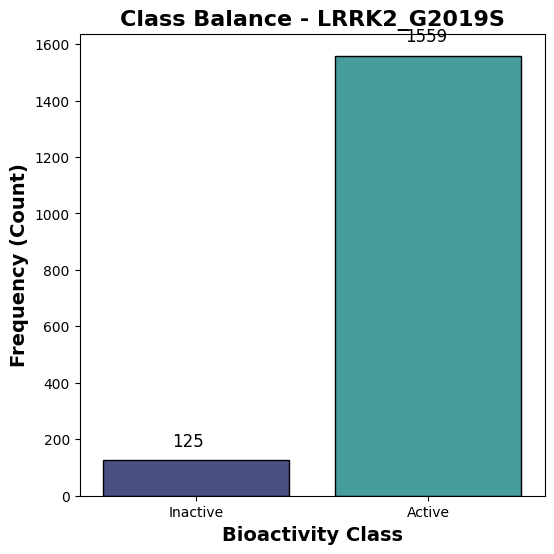

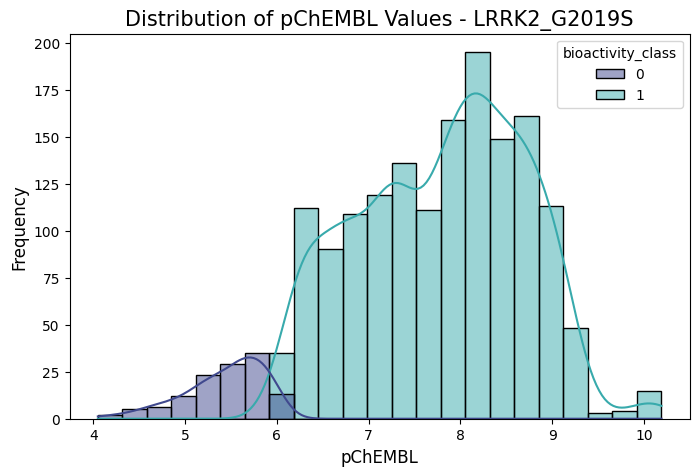

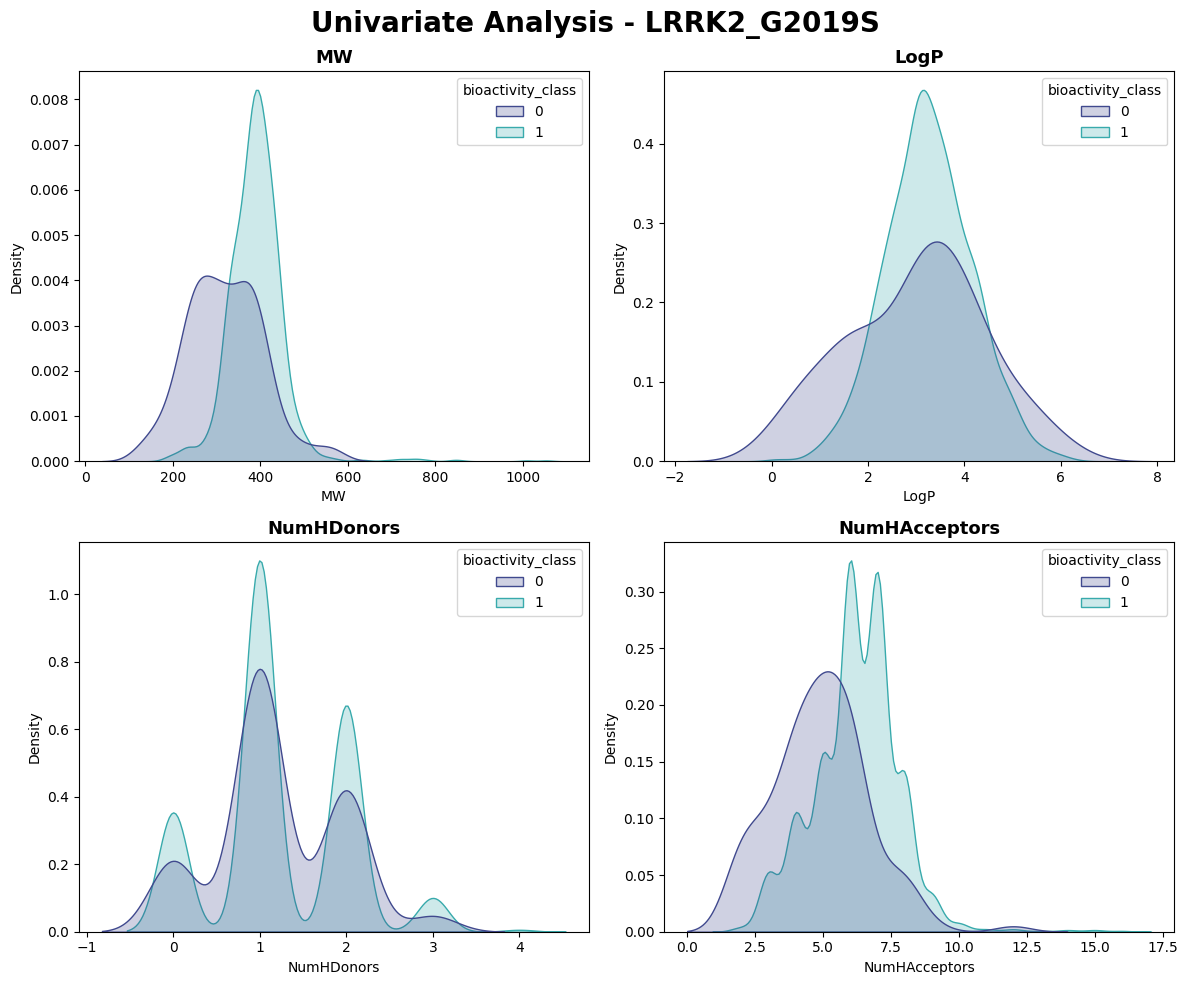

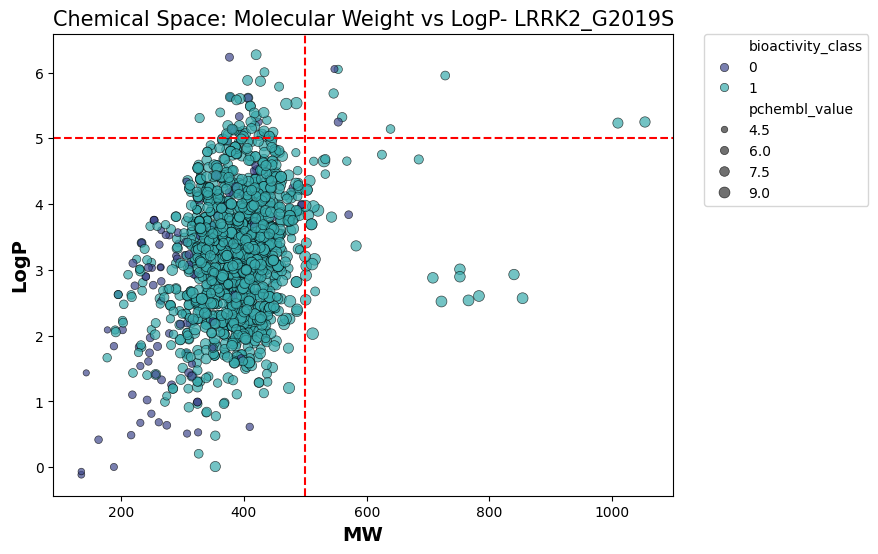

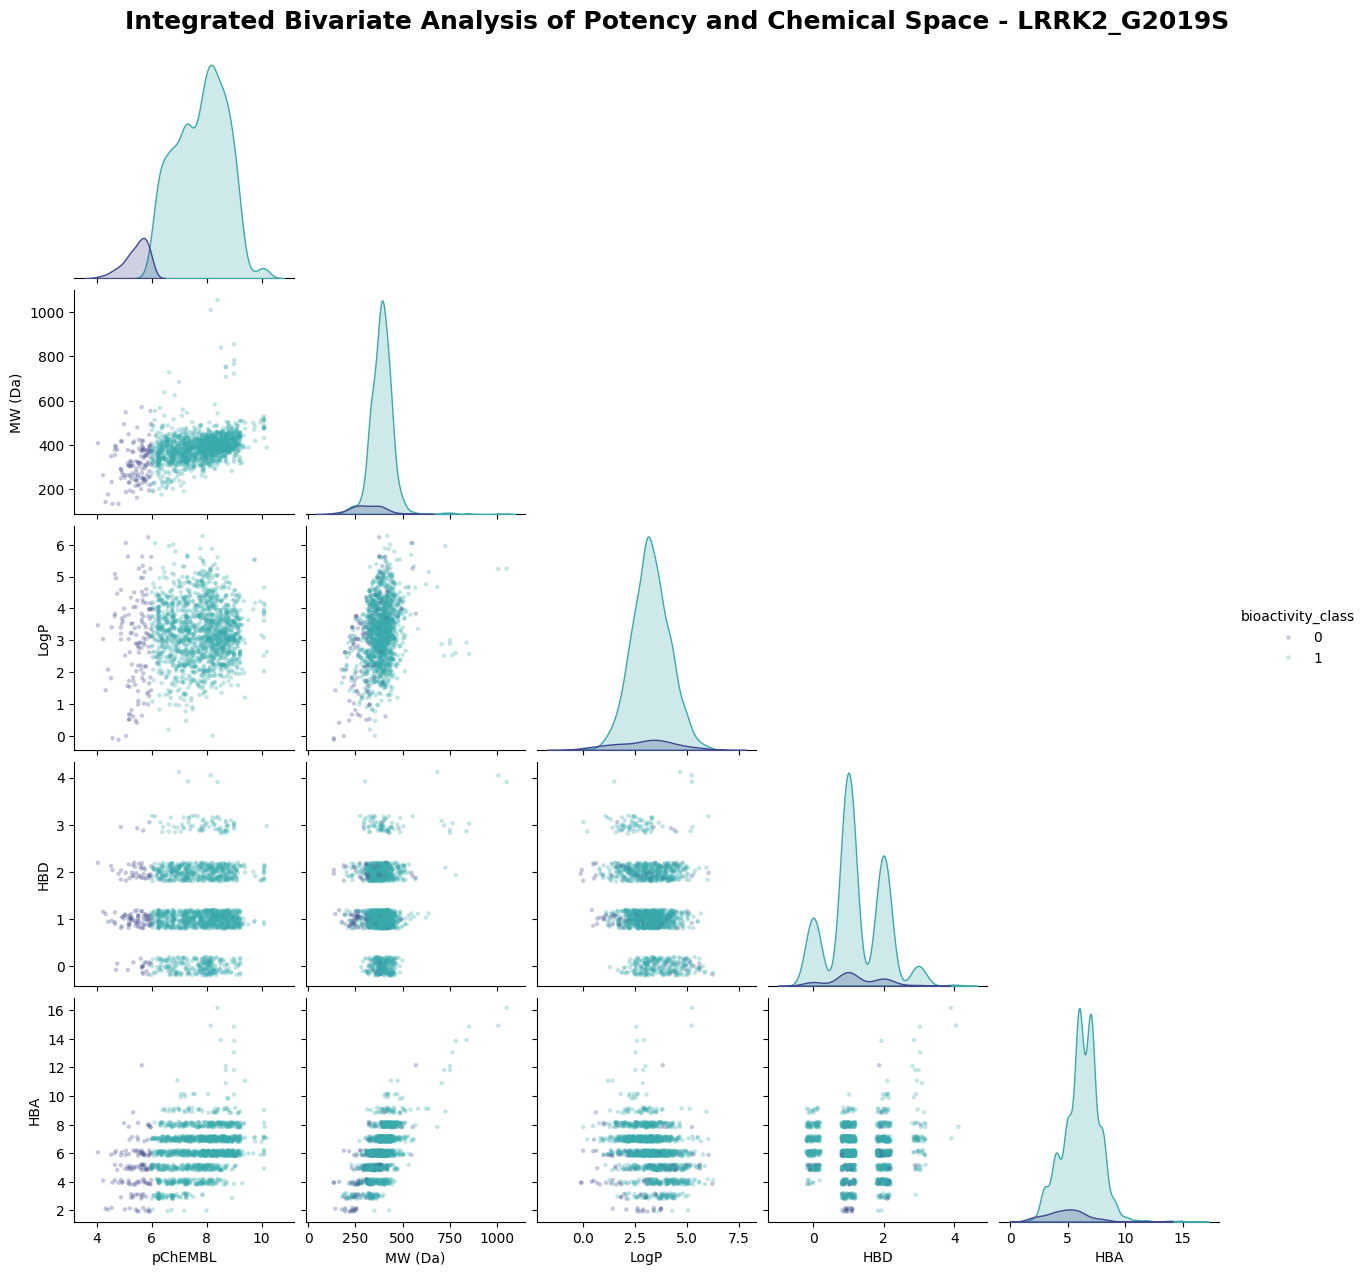

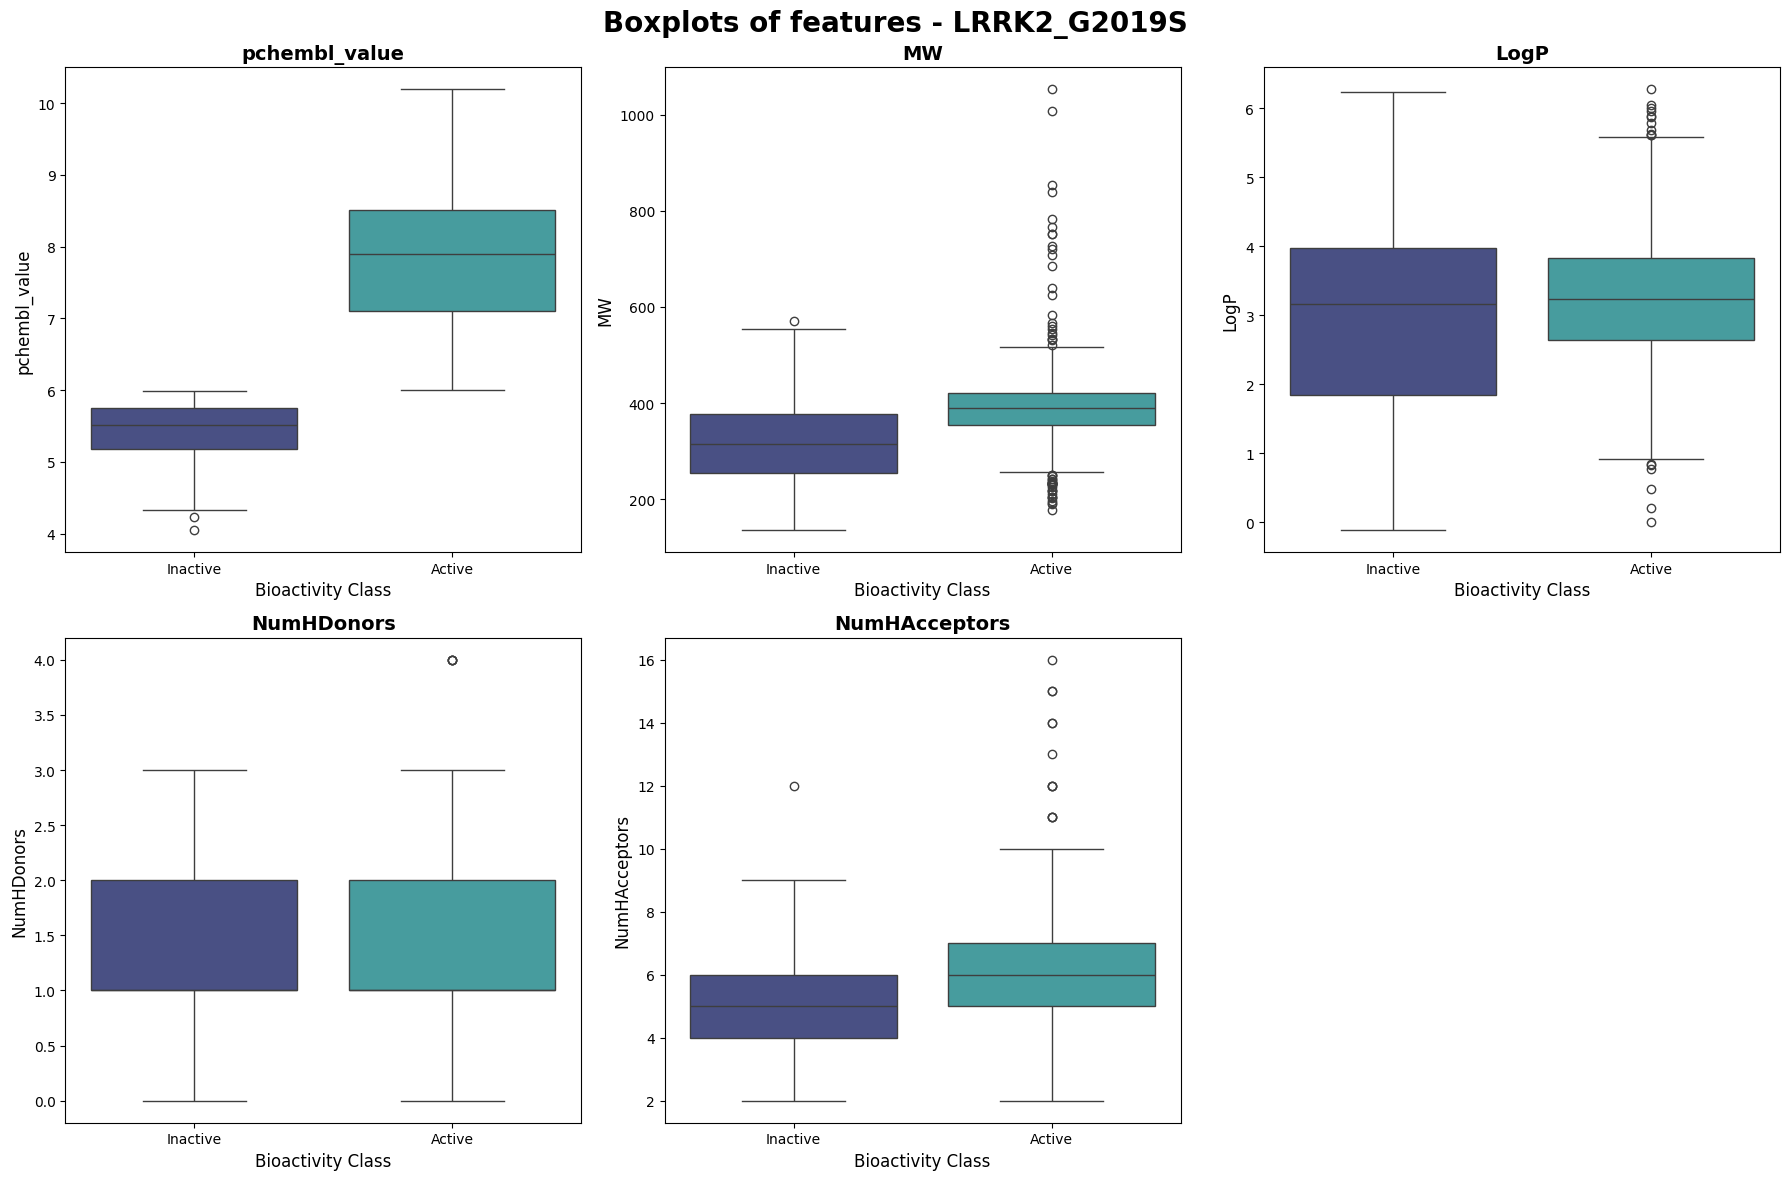

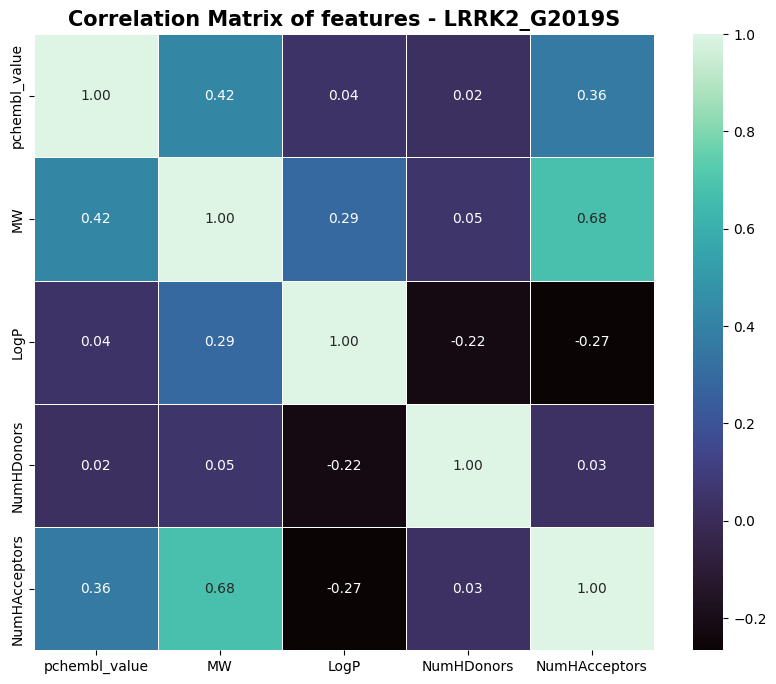

Performing the Mann-Whitney U test...
Results of Mann-Whitney U Test:
      Descriptor  Statistics             p   Interpretation
0  pchembl_value    194875.0  1.941367e-77      Significant
1             MW    148827.5  8.877156e-23      Significant
2           LogP    106648.5  7.828190e-02  Non-significant
3     NumHDonors     99243.5  7.075879e-01  Non-significant
4  NumHAcceptors    141364.0  8.297373e-18      Significant
Removing outliers by Z-score across all physicochemical descriptors...
Number of outliers removed for LRRK2_G2019S: 30
Re-plotting initial graphics after outlier removal...
Performing Exploratory Data Analysis (EDA)...


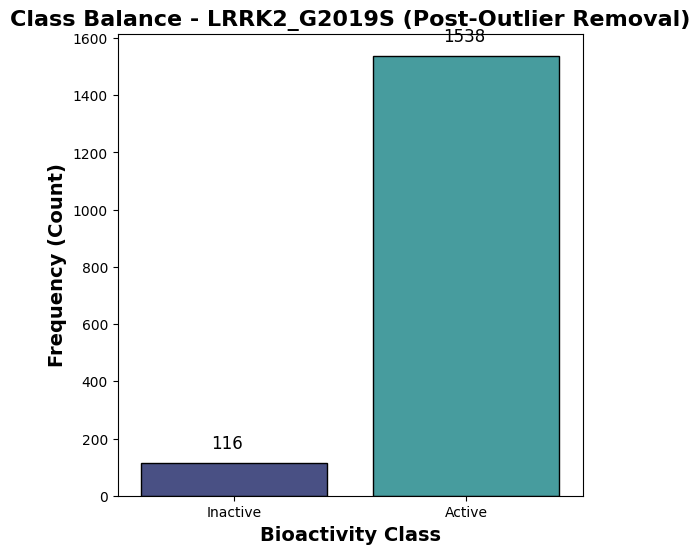

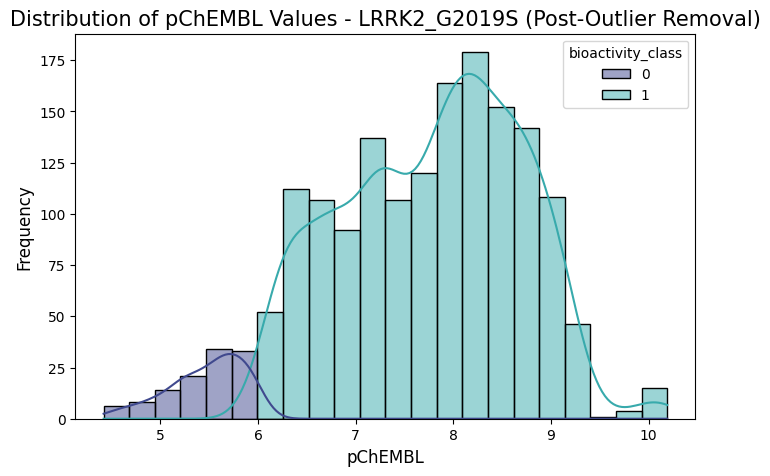

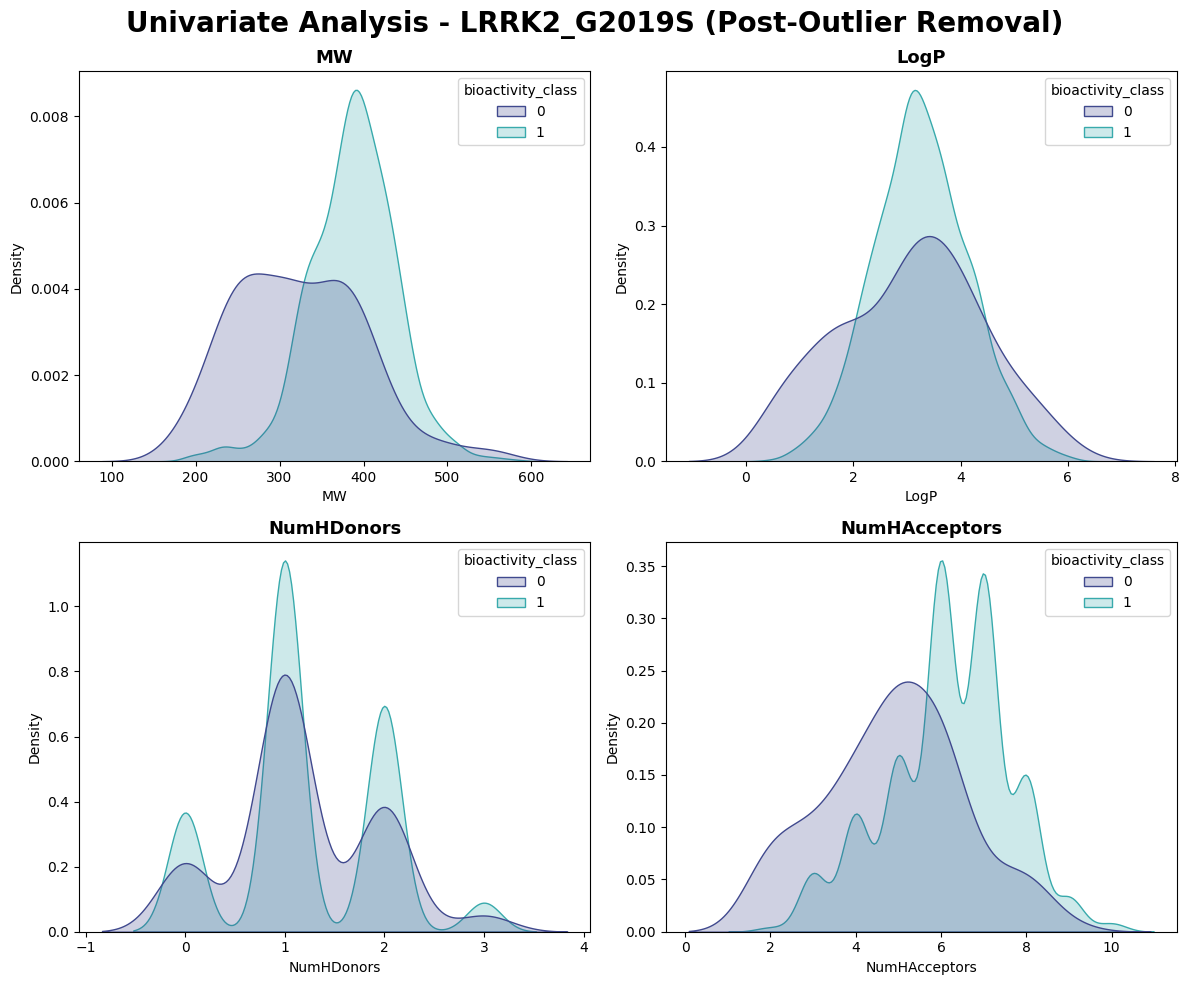

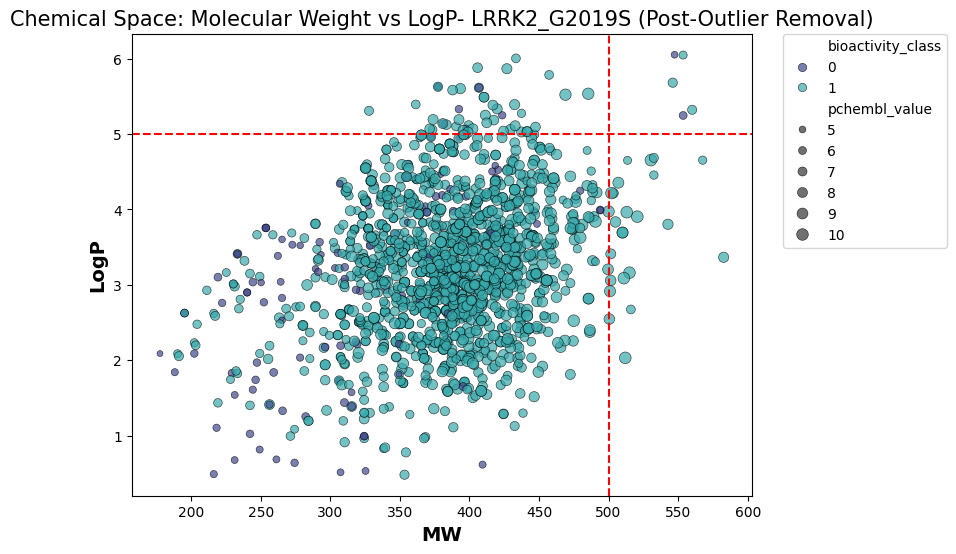

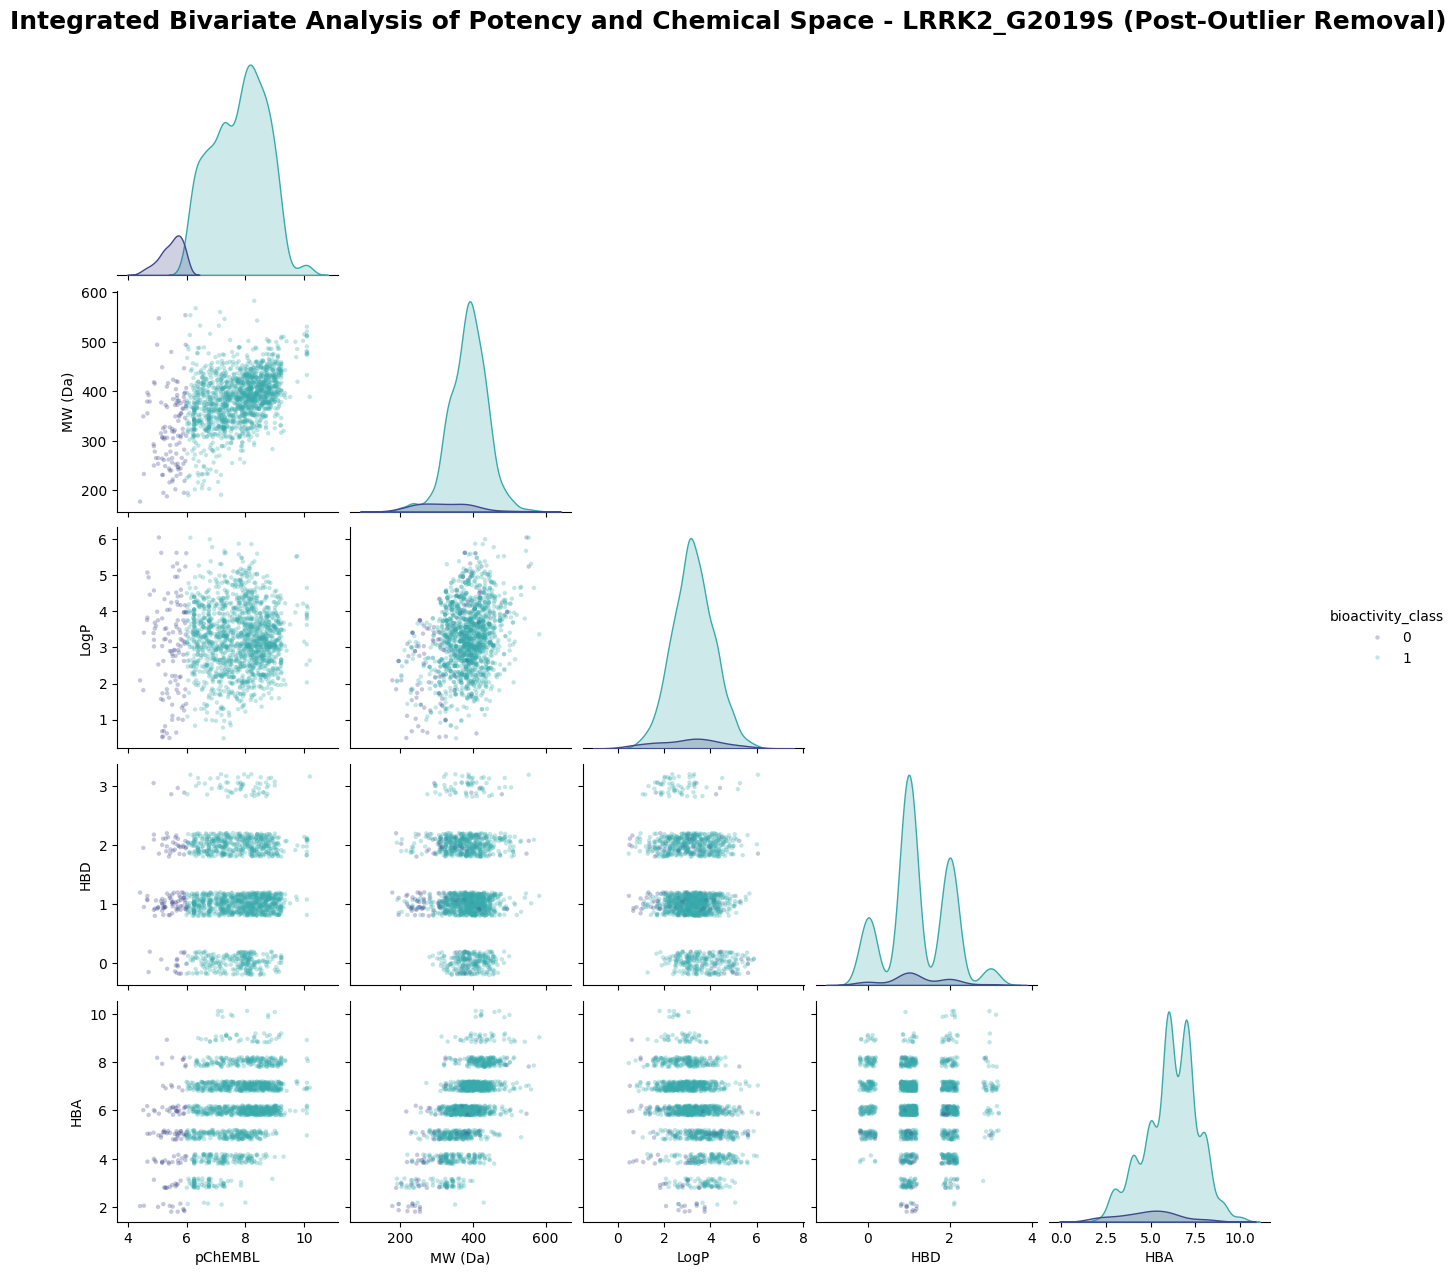

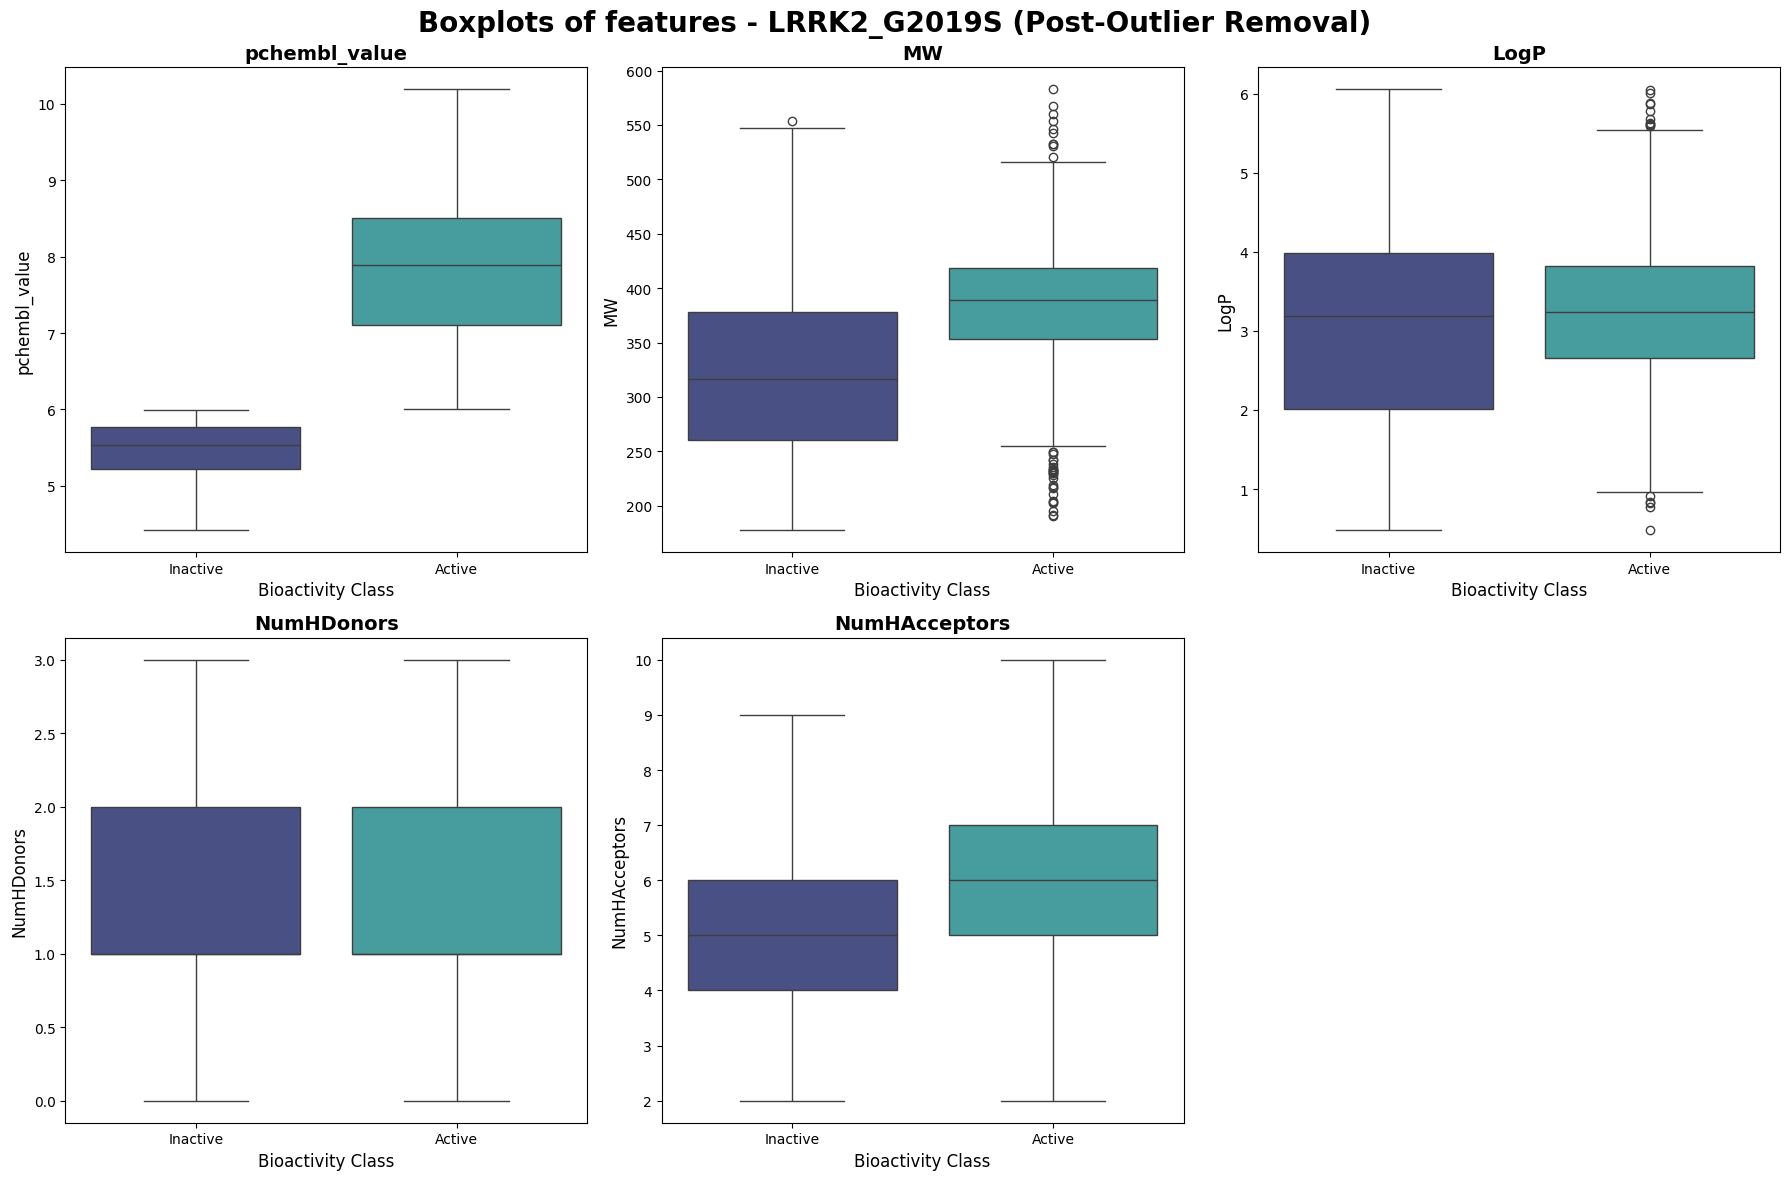

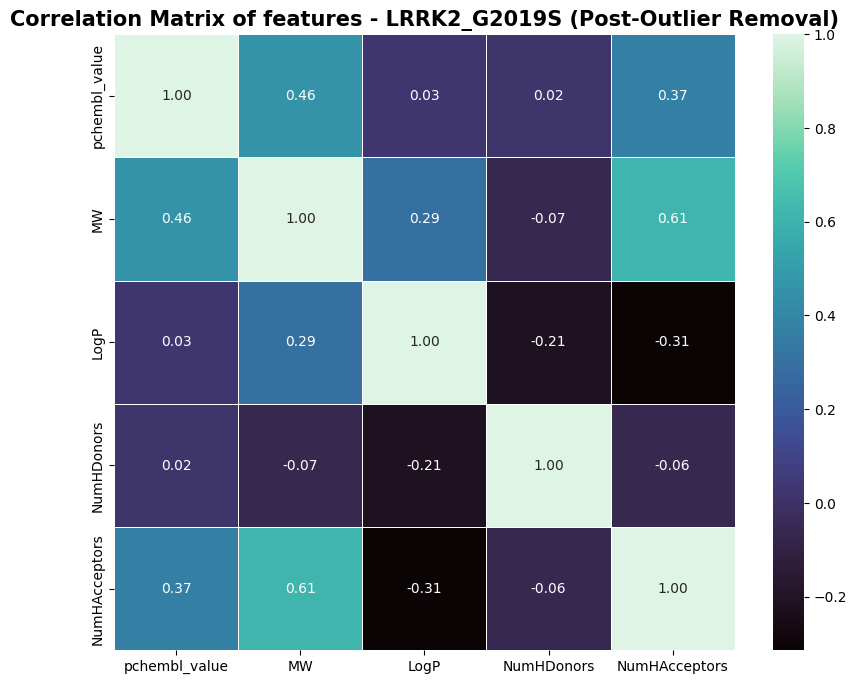

Final data (excluding extreme outliers) saved as: LRRK2_G2019S_bioactivity_data_lipinski_wo_ext_outliers.csv
--- Processing of LRRK2_G2019S complete ---



,molecule_chembl_id,canonical_smiles,pchembl_value,bioactivity_class,smiles_clean,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,4.88000,0,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,293.326,3.40042,3,5
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,5.39000,0,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,262.316,3.38422,1,4
2,CHEMBL2204495,O=C(Nc1cccnc1)c1cc(-c2ccnc(F)c2)ccc1OCc1ccccc1,7.58875,1,O=C(Nc1cccnc1)c1cc(-c2ccnc(F)c2)ccc1OCc1ccccc1,399.425,5.11400,1,4
3,CHEMBL2333124,Cc1c(-c2ccncc2)ccc2c(NC(C)C)c(C(N)=O)nnc12,5.60000,0,Cc1c(-c2ccncc2)ccc2c(NC(C)C)c(C(N)=O)nnc12,321.384,2.91942,2,5
4,CHEMBL2333123,CNC(=O)c1nnc2cc(-c3ccc(S(C)(=O)=O)cc3)ccc2c1N[...,6.69000,1,CNC(=O)c1nnc2cc(-c3ccc(S(C)(=O)=O)cc3)ccc2c1N[...,424.526,3.27030,2,6


In [46]:
# Call the function for the data (already loaded and stored in ‘df’)
df_processed = process_target_data(df.copy(), uploaded_filename.replace('_bioactivity_data_curated.csv', ''))

display(df_processed.head())